In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("=== Missing values ===")
print(df.isnull().sum())

print("\n=== Duplicate rows ===")
print("Duplicates:", df.duplicated().sum())

print("\n=== Basic stats ===")
df.describe()

=== Missing values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== Duplicate rows ===
Duplicates: 0

=== Basic stats ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


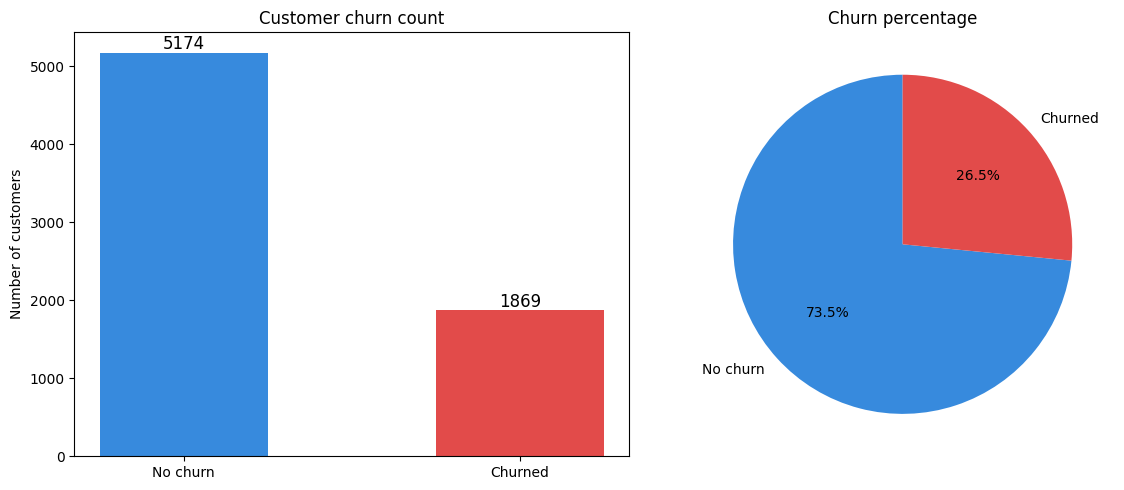


Churn rate: 26.5%


In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No churn', 'Churned'],
            churn_counts.values,
            color=['#378ADD', '#E24B4A'],
            width=0.5)
axes[0].set_title('Customer churn count')
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

axes[1].pie(churn_pct.values,
            labels=['No churn', 'Churned'],
            colors=['#378ADD', '#E24B4A'],
            autopct='%1.1f%%',  startangle=90)
axes[1].set_title('Churn percentage')

plt.tight_layout()
plt.savefig('../churn_rate.png', dpi=150)
plt.show()
print(f"\nChurn rate: {churn_pct['Yes']:.1f}%")

/tmp/ipykernel_9588/3623991199.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df,


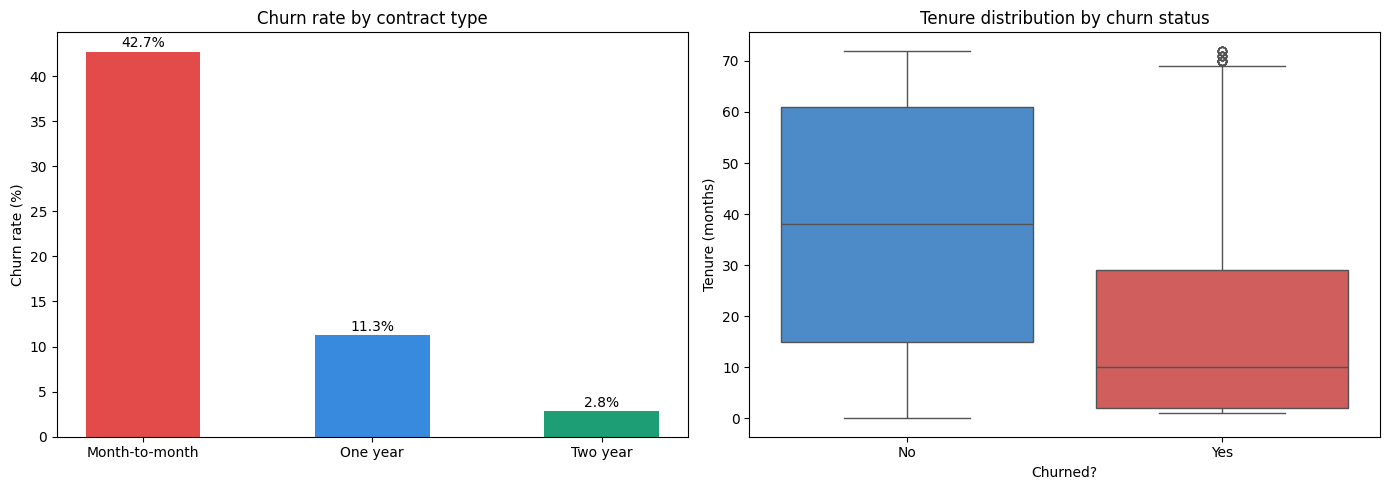

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']

axes[0].bar(contract_churn['Contract'],
            contract_churn['ChurnRate'],
            color=['#E24B4A', '#378ADD', '#1D9E75'],
            width=0.5)
axes[0].set_title('Churn rate by contract type')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_xlabel('')
for i, row in contract_churn.iterrows():
    axes[0].text(i, row['ChurnRate'] + 0.5,
                 f"{row['ChurnRate']:.1f}%", ha='center')

sns.boxplot(x='Churn', y='tenure', data=df,
            palette={'No': '#378ADD', 'Yes': '#E24B4A'},
            ax=axes[1])
axes[1].set_title('Tenure distribution by churn status')
axes[1].set_xlabel('Churned?')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.savefig('../contract_tenure_churn.png', dpi=150)
plt.show()

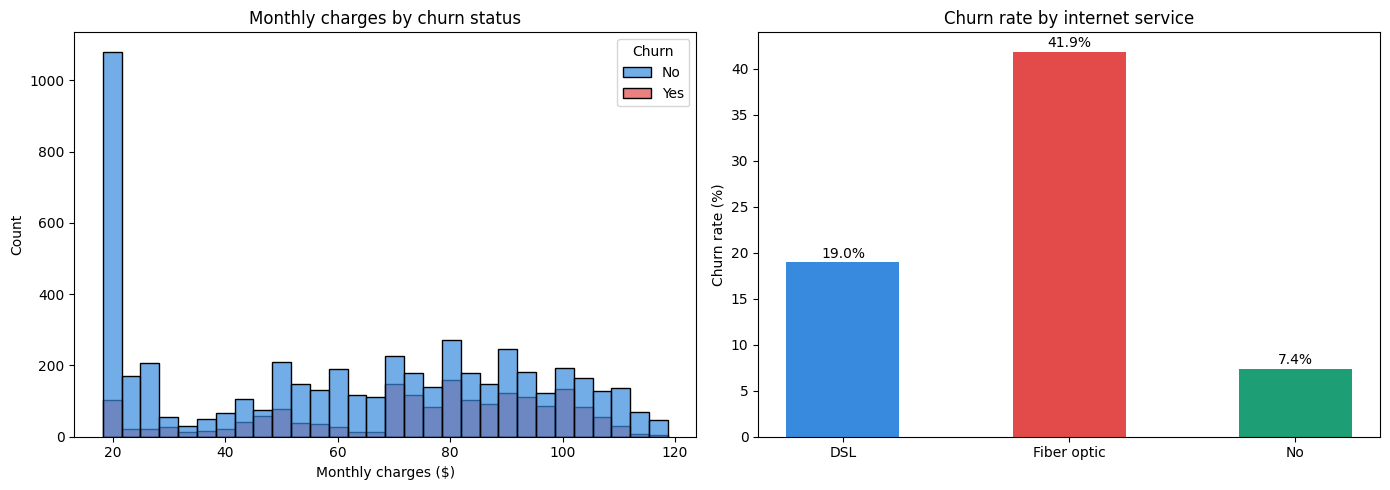

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
             bins=30, palette={'No': '#378ADD', 'Yes': '#E24B4A'},
             alpha=0.7, ax=axes[0])
axes[0].set_title('Monthly charges by churn status')
axes[0].set_xlabel('Monthly charges ($)')

internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
internet_churn.columns = ['InternetService', 'ChurnRate']

axes[1].bar(internet_churn['InternetService'],
            internet_churn['ChurnRate'],
            color=['#378ADD', '#E24B4A', '#1D9E75'],
            width=0.5)
axes[1].set_title('Churn rate by internet service')
axes[1].set_ylabel('Churn rate (%)')
for i, row in internet_churn.iterrows():
    axes[1].text(i, row['ChurnRate'] + 0.5,
                 f"{row['ChurnRate']:.1f}%", ha='center')

plt.tight_layout()
plt.savefig('../charges_internet_churn.png',  dpi=150)
plt.show()

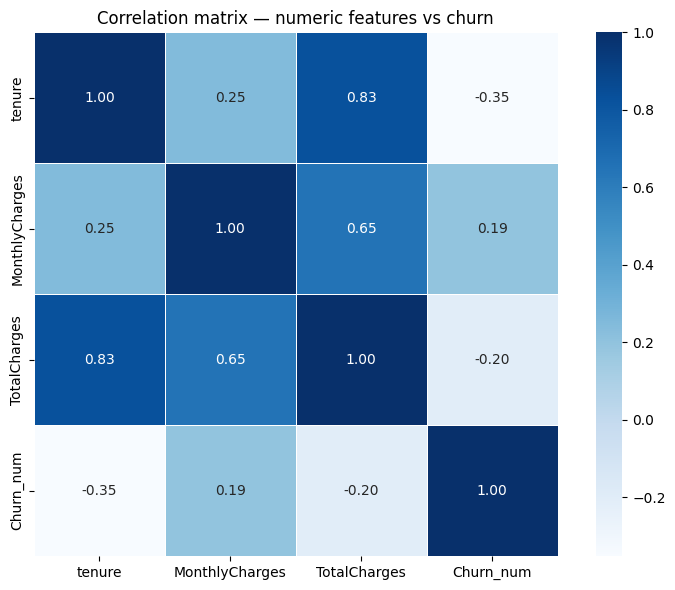

In [8]:
df_numeric = df.copy()
df_numeric['Churn_num'] = (df_numeric['Churn'] == 'Yes').astype(int)
df_numeric['TotalCharges'] = pd.to_numeric(
    df_numeric['TotalCharges'], errors='coerce')

corr = df_numeric[['tenure', 'MonthlyCharges',
                    'TotalCharges', 'Churn_num']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5,
            square=True)
plt.title('Correlation matrix — numeric features vs churn')
plt.tight_layout()
plt.savefig('../correlation_heatmap.png', dpi=150)
plt.show()

EDA summary — key findings

- Churn rate: 26.5% of customers churned
- Contract type: Month-to-month customers churn at 43%
  vs 3% for two-year contracts — strongest single predictor
- Tenure: Churned customers leave early (median ~10 months)
  vs retained customers (median ~38 months)
- Monthly charges: Churned customers pay more on average (~$74
  vs $61) — price sensitivity is a key driver
- Internet service: Fiber optic has the highest churn (~42%)
- Data issue noted: TotalCharges has 11 blank strings
   will be coerced to NaN and dropped in preprocessing